In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\dolly\Desktop\ecommerce-revenue-intelligence\data\processed\final_data_for_analysis.csv")

df.head()

,order_id,order_date,customer_id,customer_name,region,city,product_id,product_name,category,price,quantity,discount,payment_method,order_status,revenue
0,O10002,2024-09-06,C458,Bradley Higgins,South,Delhi,P5452,Jeans,Fashion,4927.0,5,15.0,UPI,Returned,0.00
1,O10002,2024-12-09,C257,Brian Peterson,West,Bangalore,P8321,Chair,Home,1411.0,3,15.0,COD,Completed,3598.05
2,O10006,2024-12-26,C455,William Haynes Dds,East,Kolkata,P8763,Headphones,Electronics,45199.0,3,5.0,Card,Completed,128817.15
3,O10007,2024-02-21,C334,Xavier Rice,South,Bangalore,P7123,Monitor,Electronics,67132.0,3,15.0,UPI,Cancelled,0.00
4,O10011,2024-12-12,C425,Bob Hernandez,East,Kolkata,P2747,Sofa,Home,3711.0,4,20.0,Card,Cancelled,0.00


In [5]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["month"] = df["order_date"].dt.month
df.head()

,order_id,order_date,customer_id,customer_name,region,city,product_id,product_name,category,price,quantity,discount,payment_method,order_status,revenue,month
0,O10002,2024-09-06,C458,Bradley Higgins,South,Delhi,P5452,Jeans,Fashion,4927.0,5,15.0,UPI,Returned,0.00,9
1,O10002,2024-12-09,C257,Brian Peterson,West,Bangalore,P8321,Chair,Home,1411.0,3,15.0,COD,Completed,3598.05,12
2,O10006,2024-12-26,C455,William Haynes Dds,East,Kolkata,P8763,Headphones,Electronics,45199.0,3,5.0,Card,Completed,128817.15,12
3,O10007,2024-02-21,C334,Xavier Rice,South,Bangalore,P7123,Monitor,Electronics,67132.0,3,15.0,UPI,Cancelled,0.00,2
4,O10011,2024-12-12,C425,Bob Hernandez,East,Kolkata,P2747,Sofa,Home,3711.0,4,20.0,Card,Cancelled,0.00,12


In [6]:
df_completed = df[df["order_status"] == "Completed"]

df_completed.head()

,order_id,order_date,customer_id,customer_name,region,city,product_id,product_name,category,price,quantity,discount,payment_method,order_status,revenue,month
1,O10002,2024-12-09,C257,Brian Peterson,West,Bangalore,P8321,Chair,Home,1411.0,3,15.0,COD,Completed,3598.05,12
2,O10006,2024-12-26,C455,William Haynes Dds,East,Kolkata,P8763,Headphones,Electronics,45199.0,3,5.0,Card,Completed,128817.15,12
6,O10016,2024-06-06,C258,Dorothy Bailey,East,Hyderabad,P2215,Laptop,Electronics,51334.0,1,15.0,COD,Completed,43633.90,6
8,O10017,2024-04-04,C356,Jose Clark,East,Hyderabad,P8288,Lamp,Home,7453.0,4,0.0,COD,Completed,29812.00,4
9,O10018,2024-07-26,C365,Kristina Brown,North,Unknown,P1402,Monitor,Electronics,5723.0,50,15.0,UPI,Completed,243227.50,7


In [7]:
df_completed.groupby("product_name")["revenue"]\
    .sum()\
    .sort_values(ascending=False)\
    .head(5)

product_name
Laptop        61975225.40
Headphones    59510938.85
Phone         52061625.90
Monitor       49647372.80
Sofa           8035771.10
Name: revenue, dtype: float64

In [8]:
df_completed.groupby("region")["revenue"]\
    .sum()\
    .sort_values(ascending=False)

region
North    89196543.50
West     67587081.25
South    65114636.55
East     42823771.45
Name: revenue, dtype: float64

In [9]:
df_completed.groupby("month")["revenue"]\
    .sum()

month
1     24322159.10
2     22894957.75
3     23937200.60
4     17624299.35
5     20854745.60
6     22567689.45
7     22270856.80
8     20590741.80
9     20025859.00
10    21828563.80
11    17827628.60
12    29977330.90
Name: revenue, dtype: float64

In [11]:
customer_data = df_completed.groupby("customer_id").agg({
    "order_id": "count",
    "revenue": "sum"
}).reset_index()

customer_data["AOV"] = round(customer_data["revenue"] / customer_data["order_id"],2)

customer_data.head()

,customer_id,order_id,revenue,AOV
0,C100,12,3027362.45,252280.20
1,C101,12,669560.20,55796.68
2,C102,9,397050.50,44116.72
3,C103,9,491111.30,54567.92
4,C104,13,179534.65,13810.36


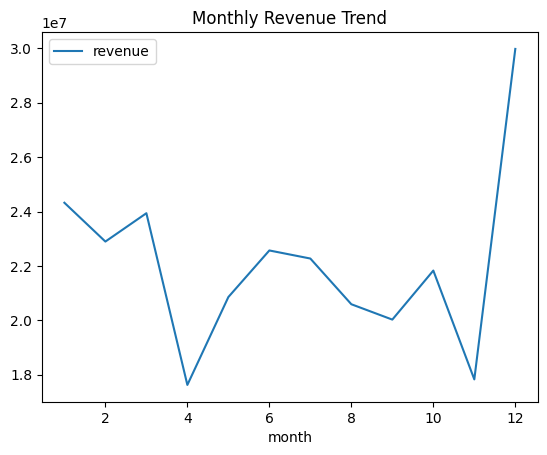

In [13]:
import matplotlib.pyplot as plt
monthly = df.groupby("month")["revenue"].sum().reset_index()

monthly.plot(x="month", y="revenue", kind="line")
plt.title("Monthly Revenue Trend")
plt.show()